**Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


d:\anaconda\envs\deepfake\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Parameters for data preprocessing**

In [ ]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths MFCC ###
# Training
data_dir = 'D:\\Stuttgart\\(important) Third Semester\\Team lab\\wav2vec_train'

# Development/Validation
dev_data_dir = 'D:\\Stuttgart\\(important) Third Semester\\Team lab\\wav2vec_dev'


**Preprocessing of training data** 

In [ ]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=32, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[[ 0.7106,  0.6576,  0.7385,  ...,  0.7515, -0.0708,  0.3243],
          [ 0.5837,  0.4663,  0.8709,  ...,  0.8026,  0.7496,  0.7424],
          [ 1.1888,  1.0922,  1.8405,  ...,  0.9806,  0.4780,  0.0490],
          ...,
          [ 1.2502,  0.9405, -0.1883,  ...,  0.3727,  0.6997,  0.8640],
          [ 0.7964,  0.7901,  1.3027,  ..., -0.0375,  1.6291,  0.1260],
          [-0.4088, -0.5944,  0.2743,  ..., -0.3642, -1.4540, -0.4494]]]])


RuntimeError: [enforce fail at alloc_cpu.cpp:116] data. DefaultCPUAllocator: not enough memory: you tried to allocate 15515504640 bytes.

**Dataset inspection**

In [ ]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([768])
First sample values:
 tensor([ 1.2272e-02,  9.3417e-01,  7.1162e-01,  5.2799e-01,  1.5975e+00,
        -8.1474e-01,  5.2147e-01, -6.5895e-01, -9.8393e-02, -8.2546e-01,
        -4.3042e-01,  2.6528e+00,  9.2680e-01,  1.2442e+00,  4.2631e-01,
        -4.4164e-01,  1.5753e+00,  3.6094e-01, -5.4281e-01, -3.3024e+00,
        -4.2227e-01, -6.0377e-01,  1.8025e+00,  1.9706e+00,  1.9256e+00,
        -1.2175e+00,  6.0522e-01, -1.1069e+00, -2.5433e-01,  2.1102e-01,
        -8.3685e-01, -4.2159e-01, -1.3527e+00,  7.6184e-02, -4.8261e-01,
         1.6650e-01, -7.2646e-01,  3.2565e-01,  8.6219e-01, -4.6660e-01,
        -1.3761e+00,  1.0278e+00, -8.1867e-01, -6.0169e-01, -3.2679e+00,
        -7.1629e-01, -1.2617e+00,  4.9999e-01, -5.8897e-03, -7.8384e-01,
        -1.7148e-01,  1.2237e+00,  1.6228e+00,  4.7740e-01,  1.5923e+00,
        -1.9763e-01,  8.0437e-01, -2.8452e-01,  8.2616e-01, -2.4331e-01,
        -2.7896e-01,  3.5944e-01, -4.0305e-01,  3.9284e-01, -4.7

**Testing the Data Loader**

In [ ]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

768
torch.Size([25380, 768])
Batch features shape: torch.Size([32, 768])


**Preprocessing and loading the Development/Validation Set**

In [ ]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([-5.3862e-01,  5.8563e-01,  1.1583e+00,  9.2064e-01,  1.5050e+00,
        -1.1412e+00,  4.3899e-01, -1.2333e+00,  2.3222e-01, -8.3351e-01,
        -6.8019e-01,  2.1907e+00,  1.0176e+00,  6.1101e-01,  5.1643e-01,
        -2.5854e-01,  1.5086e+00,  1.4794e-01, -5.5412e-01, -3.5060e+00,
        -4.8028e-01, -1.5792e-01,  1.2298e+00,  2.3608e+00,  2.0954e+00,
        -1.0556e+00,  6.4423e-01, -1.1470e+00, -8.5863e-01,  7.4281e-01,
        -1.3267e+00, -4.2876e-01, -1.8077e+00, -1.9864e-02,  1.4407e-01,
         7.4971e-01, -6.5049e-01,  4.5541e-01,  8.1285e-01, -4.4899e-01,
        -1.2360e+00, -3.0597e-01, -3.1409e-01, -1.1068e+00, -3.5636e+00,
        -1.1539e+00, -1.1587e+00,  1.0908e+00,  3.7837e-01, -8.0928e-01,
        -7.5230e-02,  1.8260e+00,  1.7338e+00,  5.0777e-02,  1.7469e+00,
        -2.9164e-01,  3.0610e-01,  5.4895e-02,  6.4108e-02,  6.2168e-02,
         1.3462e-01,  3.1412e-01, -4.3592e-01,  1.3223e-01, -1.2612e+00,
        -1.6771e-01, -6.197

**Testing the Processed Dataloaders and Label Distribution**

In [ ]:
print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([32, 768]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Training labels shape torch.Size([32])
Development features shape: torch.Size([24844, 768]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([31,  1])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [ ]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [ ]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob=0.5):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=40, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = LFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification / previous line (before BCEwithLogits): x = torch.sigmoid(self.fc3(x))
        
        return x

**Initializing the model**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [ ]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\Zheng\AppData\Local\Temp\ipykernel_24992\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 10  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.unsqueeze(1).to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            torch.save(model.state_dict(), 'wav2vec_best_model.pth')
            print("Early stopping triggered (EER did not improve).")
            break


Epoch [1/100] | Train Loss: 1.2483, Acc: 52.19% | Val Loss: 0.8843, Acc: 89.07% | Val EER: 39.67%
Epoch [2/100] | Train Loss: 1.1383, Acc: 63.46% | Val Loss: 0.8735, Acc: 89.70% | Val EER: 36.02%
Epoch [3/100] | Train Loss: 1.0938, Acc: 67.40% | Val Loss: 0.8642, Acc: 89.74% | Val EER: 32.37%
Epoch [4/100] | Train Loss: 1.0546, Acc: 68.76% | Val Loss: 0.8550, Acc: 89.76% | Val EER: 29.42%
Epoch [5/100] | Train Loss: 1.0195, Acc: 70.78% | Val Loss: 0.8479, Acc: 89.75% | Val EER: 27.04%
Epoch [6/100] | Train Loss: 0.9967, Acc: 71.62% | Val Loss: 0.8418, Acc: 89.76% | Val EER: 24.92%
Epoch [7/100] | Train Loss: 0.9799, Acc: 72.74% | Val Loss: 0.8356, Acc: 89.76% | Val EER: 23.19%
Epoch [8/100] | Train Loss: 0.9576, Acc: 73.75% | Val Loss: 0.8299, Acc: 89.75% | Val EER: 21.71%
Epoch [9/100] | Train Loss: 0.9348, Acc: 75.78% | Val Loss: 0.8245, Acc: 89.76% | Val EER: 20.32%
Epoch [10/100] | Train Loss: 0.9207, Acc: 75.87% | Val Loss: 0.8190, Acc: 89.75% | Val EER: 19.24%
Epoch [11/100] | Tr

**Plotting the results**

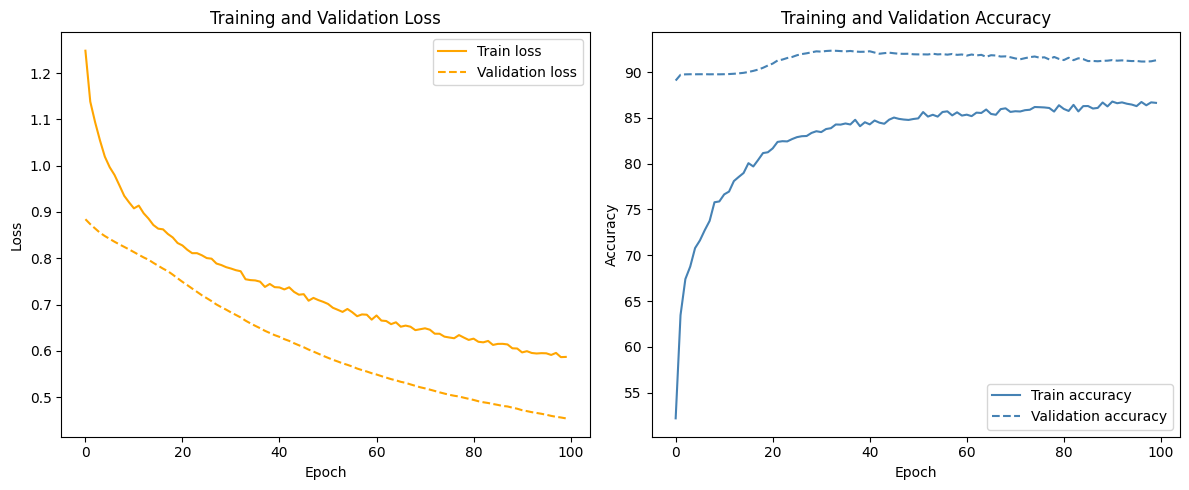

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [ ]:
torch.save(model.state_dict(), 'wav2vec_with_deepfake_audio_detection_model.pth')

**Prepare Evaluation Dataset**

In [ ]:
# Evaluation
eval_data_dir = 'D:\\Stuttgart\\(important) Third Semester\\Team lab\\wav2vec_eval'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([-5.1272e-01,  6.8493e-01,  7.2550e-01,  7.1451e-01,  1.4196e+00,
        -9.2635e-01,  6.4373e-01, -9.3604e-01,  1.8510e-01, -3.9784e-01,
        -2.9022e-01,  2.4870e+00,  9.8905e-01,  1.3387e+00,  3.5194e-01,
         2.3507e-01,  1.5486e+00,  2.4446e-01, -5.3460e-01, -2.9536e+00,
        -4.9511e-01, -2.5530e-01,  1.1690e+00,  2.1774e+00,  2.1423e+00,
        -1.4248e+00,  2.2540e-01, -8.2551e-01, -8.6540e-01,  7.1629e-01,
        -1.1340e+00, -6.4355e-02, -1.7279e+00,  1.8004e-01, -1.9416e-01,
         6.1324e-01, -7.6344e-01,  3.4524e-01,  8.0809e-01, -6.2647e-01,
        -8.8358e-01,  8.7799e-01, -6.4314e-01, -3.7328e-01, -3.3096e+00,
        -1.4700e+00, -1.0910e+00,  5.9251e-01,  4.2089e-01, -7.2609e-01,
        -3.4409e-02,  1.7478e+00,  1.7862e+00,  3.9897e-02,  1.3093e+00,
        -3.6606e-01,  6.1682e-01, -3.7302e-01,  3.0130e-01, -1.5436e-01,
        -5.2380e-01,  5.6965e-02, -5.9957e-01,  7.2755e-01, -7.6524e-01,
        -9.6542e-02, -2.210

In [ ]:
def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.unsqueeze(1).to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(np.array(all_labels), np.array(all_scores))
    prob_threshold = expit(threshold)
    preds = (np.array(all_scores) >= threshold).astype(int)
    f1 = f1_score(np.array(all_labels), preds)

    # Print results
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

evaluate_on_eval_set(model, eval_dataLoader)


Evaluation Set:
Loss: 0.4599 | Accuracy: 91.10%
EER: 10.31% | Logit Threshold: -0.2109 | Prob Threshold: 0.4475
F1 Score: 0.6424
Predictions: [1]: 13183 | [0]: 58054
